# Supply Chain Analysis

## Business Problem

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting
goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries
and unpredictable order profitability.

### Desired Outcome

The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall
profitability and efficiency.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
# Professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = "#800000"
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [ ]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/1pWKUiz4kOYDLhPhj2bDddYjgnErSR62OOn3C4gSKPL4/export?format=csv")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

## Exploratory Data Analysis (EDA)

In [ ]:
# Overview
print('Rows, Columns:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nDuplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

Rows, Columns: (180519, 53)

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Pro

**Insights:** <br>
***The dataset has 1,80,519 rows, 53 columns & 0 duplicate rows. <br> The missing values are concentrated mainly in fields that aren't necessary for delivery-performance analysis. <br> Therefore, dropping those columns rather than imputing them is reasonable.***

In [ ]:
# Data Cleaning
columns_to_drop = [
'Product Description',
'Product Image',
'Customer Email',
'Customer Password',
'Customer Fname',
'Customer Lname',
'Customer Street',
'Customer Zipcode',
'Order Zipcode',
'Longitude',
'Latitude',
'Order Item Cardprod Id',
'Order Item Id',
'Order Item Discount',
'Order Item Discount Rate',
'Order Item Product Price',
'Order Item Quantity',
'Order Item Total',
'Category Id',
'Department Id',
'Order Id',
'Order Customer Id',
'Customer Id',
'Product Card Id',
'Product Category Id',
'Benefit per order',          # identical to 'Order Profit Per Order'
'Product Status',             # have only one value
'Customer City',
'Order City',
'Order Country',
'Order State',
'Customer State',
'Market']

# Dropping columns that are either fully missing, redundant, or have only one value
df = df.drop(columns = columns_to_drop)

In [ ]:
# Removing cancelled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df [df ['Delivery Status'] != 'Shipping canceled']

In [ ]:
# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst = False)

In [ ]:
# Checking the overview again after data cleaning
print('rows, columns:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, columns: (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


**Insight:** <br>
***The dataset was reduced from: 1,80,519 to 1,72,765 orders & 53 to 20 columns <br>
So approximately 7,754 records (~4.3%) were removed, primarily because cancelled orders were excluded.***

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [ ]:
# Value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f"\n{df[col].value_counts()}")


Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Shipping Mode
Standard Class    103153
Second Class       3380

**Insight:** <br>
***Standard Class dominates the shipping mode, representing roughly 60% of the cleaned records. <br>
That means even a relatively small improvement in Standard Class performance could have a much larger overall business impact than optimizing a low-volume shipping method.***

In [ ]:
# Calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


**Insight:** <br>
***On average, actual delivery is roughly 0.54 days slower than the scheduled duration. <br>
That is a significant operational gap because it indicates that the scheduling promise and actual operational capability aren't fully aligned.***

In [ ]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
True,94523
False,78242


**Insight:** <br>
***54.71% of orders are delayed and only 45.29% are delivered within the scheduled time. <br>
A >50% delay rate indicates a systemic operational problem.***

In [ ]:
df['Order Profit Per Order']

,Order Profit Per Order
0,91.250000
1,-249.089996
2,-247.779999
3,22.860001
4,134.210007
...,...
180514,40.000000
180515,-613.770019
180516,141.110001
180517,186.229996


In [ ]:
# Profitability Flag based on Order Profit Per Order
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Profitability Flag'].value_counts()

,count
Profitability Flag,
Profit,139354
Loss,32295
Break-even,1116


In [ ]:
df['Profitability Flag'].value_counts(normalize = True)

,proportion
Profitability Flag,
Profit,0.80661
Loss,0.18693
Break-even,0.00646


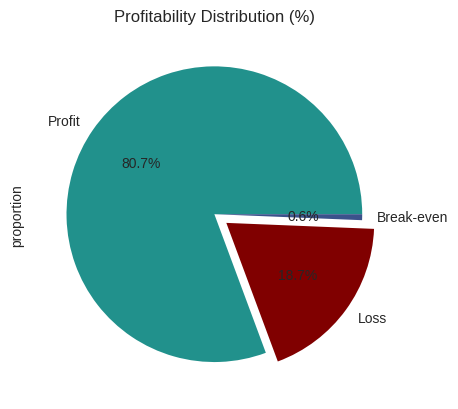

In [ ]:
# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color], explode = [0, 0.1, 0])
plt.title('Profitability Distribution (%)')
plt.show()

**Insight:** <br>
***~19% orders are loss-making. <br>
Approximately 1 in every 5 orders is loss-making. That's substantial.
The supply-chain problem isn't only affecting customer experience, It is happening alongside significant order-level profitability risk.***

In [ ]:
# Creating KPIs
def format_func(value) :
    if value >= 1e6:
        return f"{value/1e6: .1f}M $"
    elif value >= 1e3:
        return f"{value/1e3 :. 1f}K $"
    else:
        return f"{value: .0f} $"

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n --- Business KPIs --- \n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


 --- Business KPIs --- 

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit:  7.5M $
Total Loss due to delays:  2.1M $


## Profitability vs Delivery Time Analysis

In [ ]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
          mean_profit='mean',
          total_profit='sum',
          order_count='count').reset_index())

In [ ]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [ ]:
delay_distribution = (df['Delay'].value_counts(normalize=True).sort_index() * 100).reset_index()

In [ ]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


**Insight:** <br>
***Almost 31% of all orders are exactly one day late. <br>
That means the company could potentially achieve a large improvement by fixing relatively small operational inefficiencies rather than focusing exclusively on extreme cases.***


Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


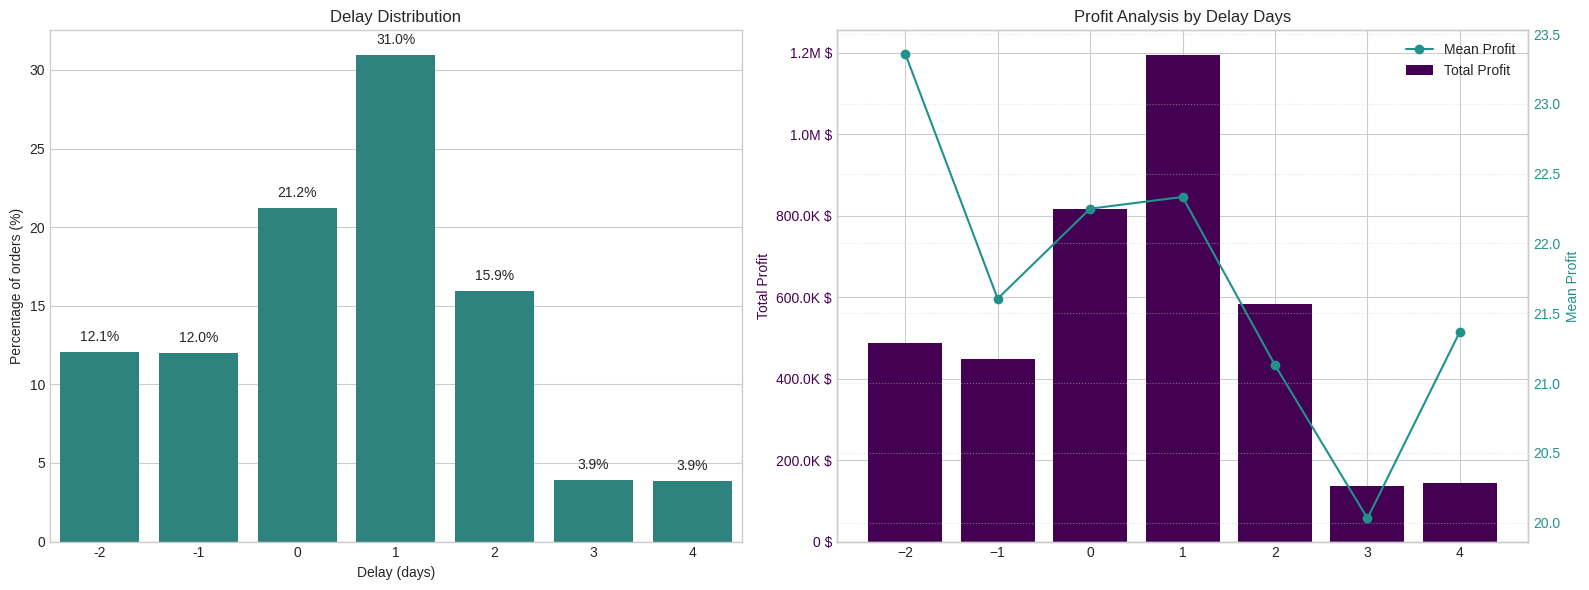

In [ ]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of orders (%)')

# Percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** <br>
***The relationship between delay and average order profit is not dramatically linear. <br>
Profit falls somewhat as delays become longer, but the difference isn't huge. <br>
Therefore the major business problem is the volume of delayed orders rather than an extremely strong per-order profit collapse caused by every additional day of delay. An odd observation is that the average profit is much more when order is delayed by 4 days.***

## Bottleneck Detection

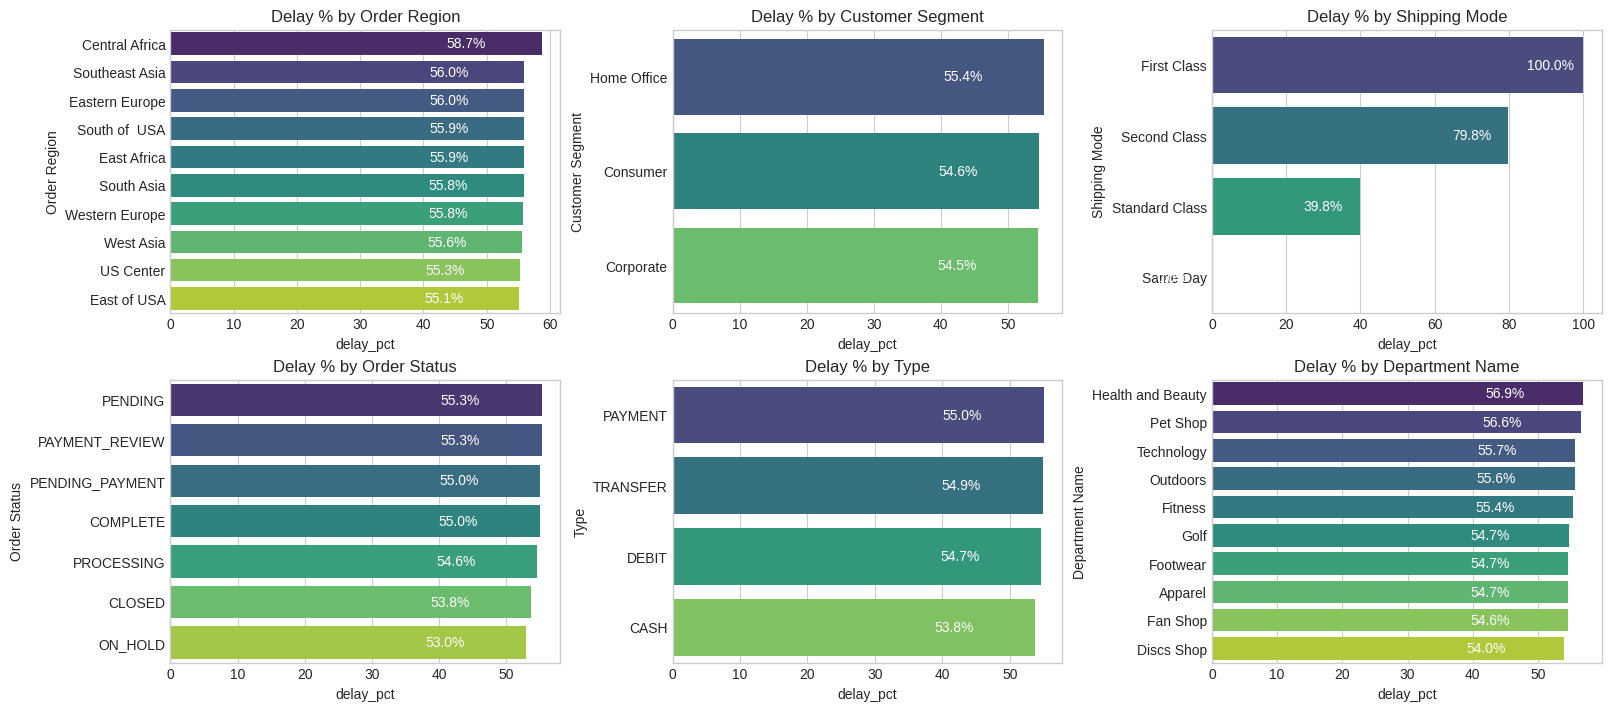

In [ ]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax. set_title(f'Delay % by {category}')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color = 'white')

plt.show()

**Insights:** <br>
***Shipping mode is a very strong differentiator.
First Class has a 100% observed delay rate in this analysis. Second Class is also extremely problematic at almost 80%. Meanwhile Standard Class is around 40%.*** <br>
<br>
**Business Implications:** <br>
***Management should investigate: <br>
carrier assignment <br>
First/Second Class service-level agreements <br>
route selection <br>
fulfillment-center allocation <br>
capacity constraints <br>
handoffs <br>
promised delivery dates <br>
before simply increasing shipping speed or cost. <br>
<br>
Department-level differences are present, but they aren't nearly as dramatic as shipping-mode differences. <br>
Therefore, department should probably be used for secondary optimization, not as the primary intervention. <br>
The presence of high delay rates in payment-related statuses suggests there could be an opportunity to investigate whether payment verification/authorization is contributing to fulfillment delays.***

## Root Cause Analysis

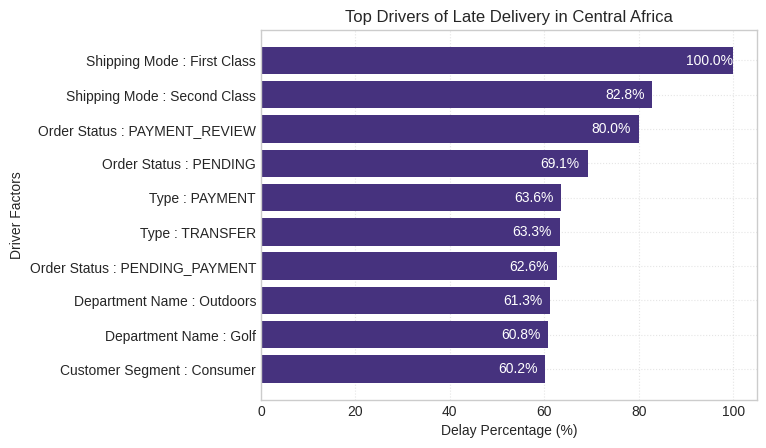

In [ ]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor).agg(
            total_orders=('Delay', 'count'),
            late_orders=('Is_Delayed', 'sum'),
            avg_delay=('Delay', 'mean')).reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                f"{width:.1f}%",
                va='center', fontsize = 10, color = 'white')

    plt.show()

top_drivers_for_region('Central Africa')

## Time-Based Analysis

In [ ]:
# Checking date range (min & max)
print('Start date:', df['shipping date (DateOrders)'].min())
print('End date:', df['shipping date (DateOrders)'].max())

Start date: 2015-01-03 00:00:00
End date: 2018-02-06 22:14:00


In [ ]:
# Delay % by Month, Day of Week & Hour

delay_by_month = (df.groupby('order_month')['Is_Delayed'].mean().reset_index())

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (df.groupby('order_day')['Is_Delayed'].mean().reset_index())

delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (df.groupby('order_hour')['Is_Delayed'].mean().reset_index())

delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [ ]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


In [ ]:
delay_by_day

,order_day,Is_Delayed,delay_pct
0,Friday,0.544884,54.488442
1,Monday,0.555338,55.533838
2,Saturday,0.542619,54.261937
3,Sunday,0.551524,55.152418
4,Thursday,0.547202,54.720188
5,Tuesday,0.539841,53.984137
6,Wednesday,0.548452,54.845175


In [ ]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


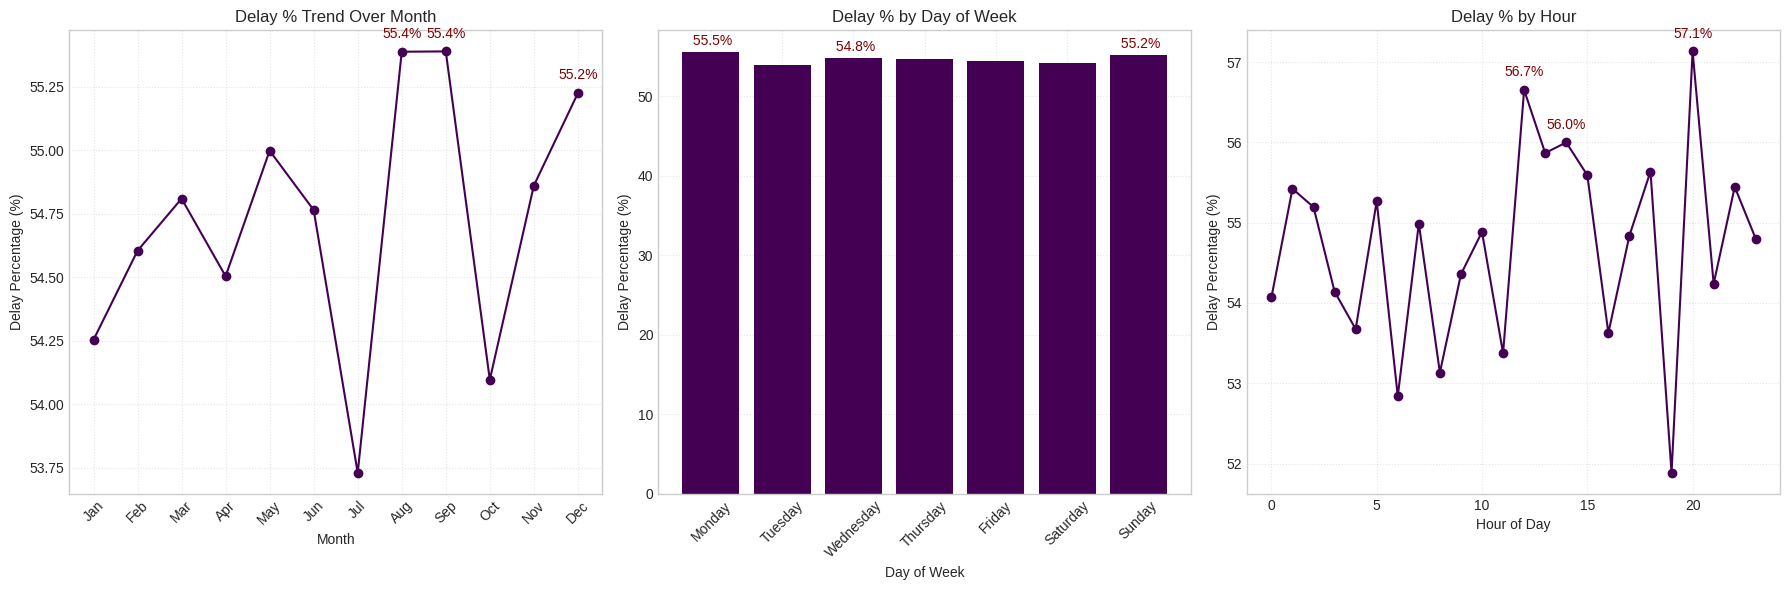

In [ ]:
# Plotting Delay % by Month, Day of Week & Hour
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f' {height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

**Insights:** <br>
***Month: August, September & December has relatively more delay. <br>
Weekday: No any major differences observed. <br>
Hour: Relatively more delay around 7pm & 12pm.***

## Machine Learning Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In this dataset, Random Forest Model is the best fit (More Accuracy).

Dataset is quite unbalanced, therefore to balance it, import SMOTE

In [ ]:
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region',
        'Shipping Mode', 'order_month', 'order_hour']]
y = df['Late_delivery_risk']

In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']). columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding (low dimensional and robust for high cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# use encoded features for modeling
X = X_encoded

# train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


In [ ]:
X_encoded

,Days for shipment (scheduled),order_month,order_hour,Type_freq,Category Name_freq,Customer Segment_freq,Department Name_freq,Order Region_freq,Shipping Mode_freq
0,4,1,22,0.401094,0.001945,0.517582,0.013741,0.052881,0.597071
1,4,1,12,0.243851,0.001945,0.517582,0.013741,0.043151,0.597071
2,4,1,12,0.113542,0.001945,0.517582,0.013741,0.043151,0.597071
3,4,1,11,0.401094,0.001945,0.178375,0.013741,0.056337,0.597071
4,4,1,11,0.241513,0.001945,0.304043,0.013741,0.056337,0.597071
...,...,...,...,...,...,...,...,...,...
180514,4,1,3,0.113542,0.096055,0.178375,0.370636,0.040361,0.597071
180515,2,1,1,0.401094,0.096055,0.304043,0.370636,0.040361,0.195676
180516,4,1,21,0.243851,0.096055,0.304043,0.370636,0.056337,0.597071
180517,4,1,20,0.241513,0.096055,0.517582,0.370636,0.056337,0.597071


In [ ]:
y.value_counts()

,count
Late_delivery_risk,
1,98977
0,73788


In [ ]:
# Balancing the training data using SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n --- {model_name} --- ")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall:", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [ ]:
# Fit the Random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


 --- Random Forest Classifier --- 
Accuracy: 0.74
Precision: 0.79
Recall: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553



**Insight:** <br>
***74% accuracy and 75% recall of this model means, it can identify a substantial portion of risky deliveries.
For business operations, that's useful because the company could potentially flag risky orders before they become late.***

## Business Insights

***1. Delivery reliability is the biggest problem <br>
   54.71% of orders are delayed. <br>
   <br>
2. Most delays are manageable <br>
   31% of orders are only one day late. <br>
   <br>
3. Shipping mode is the strongest operational signal <br>
   First Class has 100% delay, while Second Class has 79.8%. <br>
   <br>
4. The problem isn't isolated geographically <br>
   Central Africa has the highest delay of 58.7%, but many regions remain around 55–56%. This indicates a broader supply-chain issue. <br>
   <br>
5. Customer segment isn't a major differentiator <br>
   Consumer, Corporate and Home Office all have roughly 54–55% delay rates. <br>
   <br>
6. Time isn't the main problem <br>
   Monthly, weekday and hourly delay rates remain relatively close to each other. <br>
   <br>
7. Profitability is vulnerable <br>
   About 18.7% of orders are loss-making. <br>
   <br>
8. Predictive intervention is feasible <br>
   The Random Forest model achieves 74% accuracy, 79% precision and 75% recall, suggesting that high-risk orders can potentially be identified proactively.***

## Business Recommendations

***1. Reassess First Class and Second Class shipping. <br>
2. Build a High-Risk Shipment alert system using Random Forest model to assign every new order a probability of Late Delivery. <br>
3. Focus on the 1-day delay problem because 30.97% of orders are exactly one day late. <br>
4. Create regional logistics strategies. <br>
5. Introduce dynamic delivery promises. For a high-risk route, the company could give a slightly longer but more realistic ETA. <br>
6. Investigate payment-review bottlenecks. In Central Africa, PAYMENT_REVIEW has an 80% delay rate. <br>
7. Optimize the carrier/route combination. <br>
8. Track profitability and delivery together. A faster shipping method may cost more and reduce margins. Choose the lowest-cost shipping option that keeps the predicted late-delivery risk below an acceptable threshold.***

## Summary

**The analysis of 172K+ completed orders revealed that 54.7% of shipments were delayed, with the majority of delays concentrated around one day. Shipping mode emerged as the strongest operational differentiator, with First Class and Second Class showing exceptionally high delay rates. Central Africa was the highest-risk region, while customer segment and time-based factors showed relatively limited variation. A Random Forest model achieved 74% accuracy with 79% precision and 75% recall, demonstrating the potential to proactively identify high-risk shipments. The key recommendation is to combine predictive risk scoring with region and shipping mode specific logistics strategies to improve delivery reliability while protecting profitability.**